In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
class PhysicsNN(nn.Module):
    def __init__(self):
        super(PhysicsNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 2)  # outputs position and velocity
        )

    def forward(self, t):
        return self.network(t)

In [3]:
def lagrangian(q, q_dot, k=1.0, m=1.0):
    """
    Lagrangian for simple harmonic oscillator
    L = T - V = (1/2)m(dx/dt)^2 - (1/2)kx^2
    """
    kinetic = 0.5 * m * q_dot**2
    potential = 0.5 * k * q**2
    return kinetic - potential

In [4]:
def compute_loss(model, t_batch):
    """
    Compute the physics-informed loss using the principle of least action
    S = ∫L dt should be stationary (δS = 0)
    """
    t_batch.requires_grad_(True)

    # Get position and velocity predictions
    predictions = model(t_batch)
    q = predictions[:, 0]  # position
    q_dot = predictions[:, 1]  # velocity

    # Compute Lagrangian at each time point
    L = lagrangian(q, q_dot)

    # Compute action by integrating the Lagrangian
    # Using trapezoidal rule for numerical integration
    dt = t_batch[1] - t_batch[0]
    action = torch.trapz(L, t_batch.squeeze())

    # For least action principle, we want variations of the action to be zero
    # We can compute this by taking gradients with respect to the path
    action_gradient = torch.autograd.grad(action, model.parameters(), create_graph=True)

    # The sum of squared gradients should be minimized
    return sum(torch.sum(grad**2) for grad in action_gradient)

In [5]:
# Training setup
model = PhysicsNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Generate time points for training
t = torch.linspace(0, 10, 100).reshape(-1, 1)

# Training loop
n_epochs = 10000
for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss = compute_loss(model, t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.6f}')

Epoch 100, Loss: 0.046107
Epoch 200, Loss: 0.008438
Epoch 300, Loss: 0.004355
Epoch 400, Loss: 0.003929
Epoch 500, Loss: 0.003642
Epoch 600, Loss: 0.003358
Epoch 700, Loss: 0.003080
Epoch 800, Loss: 0.002814
Epoch 900, Loss: 0.002560
Epoch 1000, Loss: 0.002321
Epoch 1100, Loss: 0.002096
Epoch 1200, Loss: 0.001977
Epoch 1300, Loss: 0.001692
Epoch 1400, Loss: 0.001571
Epoch 1500, Loss: 0.001346
Epoch 1600, Loss: 0.001189
Epoch 1700, Loss: 0.001231
Epoch 1800, Loss: 0.000918
Epoch 1900, Loss: 0.000800
Epoch 2000, Loss: 0.000899
Epoch 2100, Loss: 0.000599
Epoch 2200, Loss: 0.000513
Epoch 2300, Loss: 0.000496
Epoch 2400, Loss: 0.000371
Epoch 2500, Loss: 0.000311
Epoch 2600, Loss: 0.000324
Epoch 2700, Loss: 0.000217
Epoch 2800, Loss: 0.000178
Epoch 2900, Loss: 0.000157
Epoch 3000, Loss: 0.000120
Epoch 3100, Loss: 0.000097
Epoch 3200, Loss: 0.068192
Epoch 3300, Loss: 0.000064
Epoch 3400, Loss: 0.000051
Epoch 3500, Loss: 0.000041
Epoch 3600, Loss: 0.087828
Epoch 3700, Loss: 0.000028
Epoch 3800

In [6]:
# Generate predictions
with torch.no_grad():
    predictions = model(t)
    positions = predictions[:, 0].numpy()
    velocities = predictions[:, 1].numpy()

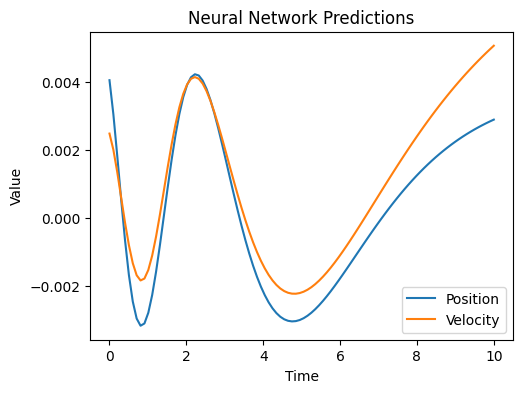

In [10]:
# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t.detach().numpy(), positions, label='Position')
plt.plot(t.detach().numpy(), velocities, label='Velocity')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Neural Network Predictions')
plt.legend()

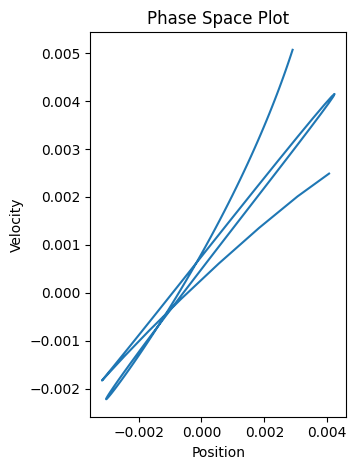

In [9]:
# Plot phase space
plt.subplot(1, 2, 2)
plt.plot(positions, velocities)
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space Plot')

plt.tight_layout()
plt.show()

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

class HamiltonianNet(nn.Module):
    """
    Neural network that learns the Hamiltonian of the system.
    For a simple harmonic oscillator, H = T + V = p²/2m + kx²/2
    """
    def __init__(self):
        super(HamiltonianNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 64),  # Input: (position, momentum)
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)   # Output: scalar Hamiltonian
        )
        
    def forward(self, x):
        # x should be a tensor containing position and momentum
        return self.network(x)
    
    def get_gradients(self, x):
        """
        Compute gradients of Hamiltonian with respect to position and momentum
        These give us the equations of motion:
        dx/dt = ∂H/∂p
        dp/dt = -∂H/∂x
        """
        x.requires_grad_(True)
        H = self.forward(x)
        (dH,) = torch.autograd.grad(H.sum(), x, create_graph=True)
        return dH

def integrate_hamilton(model, x0, p0, t, steps=100):
    """
    Symplectic integration of Hamilton's equations
    Uses leapfrog integration to preserve energy
    """
    dt = t[1] - t[0]
    trajectory = torch.zeros((len(t), 2), dtype=torch.float32)
    trajectory[0] = torch.tensor([x0, p0], dtype=torch.float32)
    
    for i in range(1, len(t)):
        x = trajectory[i-1].clone()  # Get previous state
        
        # Leapfrog integration
        dH = model.get_gradients(x)
        
        # Half step in momentum
        p_half = x[1] - 0.5 * dt * dH[0]  # p -= dt/2 * dH/dx
        # Full step in position
        x_new = x[0] + dt * dH[1]        # x += dt * dH/dp
        
        # Update x tensor with new values
        x = torch.tensor([x_new, p_half], dtype=torch.float32)
        
        # Final half step in momentum
        dH = model.get_gradients(x)
        p_new = p_half - 0.5 * dt * dH[0]  # p -= dt/2 * dH/dx
        
        # Store new state
        trajectory[i] = torch.tensor([x_new, p_new], dtype=torch.float32)
    
    return trajectory

def compute_loss(model, trajectory, t, x0=1.0, p0=0.0):
    """
    Compute loss based on:
    1. Conservation of energy (Hamiltonian should be constant)
    2. Initial conditions
    3. Hamilton's equations
    """
    # Compute Hamiltonian along trajectory
    H = model(trajectory)
    
    # Energy conservation loss: variance of Hamiltonian should be zero
    H_mean = H.mean()
    conservation_loss = ((H - H_mean)**2).mean()
    
    # Initial condition loss
    ic_loss = (trajectory[0, 0] - x0)**2 + (trajectory[0, 1] - p0)**2
    
    # Hamilton's equations loss
    dH = model.get_gradients(trajectory)
    dx_dt = torch.gradient(trajectory[:, 0], spacing=(t,))[0]
    dp_dt = torch.gradient(trajectory[:, 1], spacing=(t,))[0]
    
    dynamics_loss = ((dx_dt - dH[:, 1])**2).mean() + ((dp_dt + dH[:, 0])**2).mean()
    
    # Total loss
    total_loss = conservation_loss + 100.0 * ic_loss + dynamics_loss
    return total_loss

# Setup
model = HamiltonianNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Time points
t = torch.linspace(0, 10, 100)

# Initial conditions
x0, p0 = 1.0, 0.0

# Training loop
n_epochs = 2000
for epoch in range(n_epochs):
    optimizer.zero_grad()
    
    # Generate trajectory
    trajectory = integrate_hamilton(model, x0, p0, t)
    
    # Compute and backpropagate loss
    loss = compute_loss(model, trajectory, t, x0, p0)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 200 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.6f}')

# Generate final trajectory
with torch.no_grad():
    final_trajectory = integrate_hamilton(model, x0, p0, t)
    positions = final_trajectory[:, 0].numpy()
    momenta = final_trajectory[:, 1].numpy()
    
    # Compute Hamiltonian (energy) along trajectory
    energies = model(final_trajectory).numpy()

# Plotting
plt.figure(figsize=(15, 5))

# Position and momentum vs time
plt.subplot(1, 3, 1)
plt.plot(t.numpy(), positions, label='Position')
plt.plot(t.numpy(), momenta, label='Momentum')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Hamiltonian Neural Network Predictions')
plt.legend()

# Phase space
plt.subplot(1, 3, 2)
plt.plot(positions, momenta)
plt.xlabel('Position')
plt.ylabel('Momentum')
plt.title('Phase Space Plot')

# Energy conservation
plt.subplot(1, 3, 3)
plt.plot(t.numpy(), energies, 'r-', label='Total Energy')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Total Energy Over Time')
plt.legend()

plt.tight_layout()
plt.show()

# Print energy statistics
print(f"Energy statistics:")
print(f"Mean energy: {np.mean(energies):.6f}")
print(f"Energy standard deviation: {np.std(energies):.6f}")
print(f"Relative energy fluctuation: {np.std(energies)/np.mean(energies)*100:.2f}%")

Epoch 200, Loss: 0.057485
Epoch 400, Loss: 0.002840
Epoch 600, Loss: 0.027675
Epoch 800, Loss: 0.005697
Epoch 1000, Loss: 0.060737
Epoch 1200, Loss: 0.022006
Epoch 1400, Loss: 0.264609
Epoch 1600, Loss: 0.021225
Epoch 1800, Loss: 0.180456
Epoch 2000, Loss: 0.526540


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn